Mount Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import (
    ResNet50,
    EfficientNetB0
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Datasets path

In [3]:
train_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/train/images"

val_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/validation/images"

Class names

In [4]:
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6


Custom Cell generator

In [5]:
custom_train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

custom_val_datagen = ImageDataGenerator(
    rescale=1/255
)

custom_train_generator = custom_train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

custom_val_generator = custom_val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


Improved Custom CNN

In [ ]:
custom_cnn = Sequential([

    Input(shape=(224, 224, 1)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        6,
        activation="softmax"
    )
])

Compile

In [ ]:
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

Train Custom CNN

In [ ]:
history_custom = custom_cnn.fit(
    custom_train_generator,
    validation_data=custom_val_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 782s 17s/step - accuracy: 0.6375 - loss: 0.9871 - val_accuracy: 0.3028 - val_loss: 1.7811 - learning_rate: 0.0010
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 278s 6s/step - accuracy: 0.7590 - loss: 0.6332 - val_accuracy: 0.1833 - val_loss: 2.2551 - learning_rate: 0.0010
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 271s 6s/step - accuracy: 0.8236 - loss: 0.5016 - val_accuracy: 0.3917 - val_loss: 2.4048 - learning_rate: 0.0010
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 284s 6s/step - accuracy: 0.8611 - loss: 0.4010 - val_accuracy: 0.2194 - val_loss: 2.7173 - learning_rate: 2.0000e-04
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 284s 6s/step - accuracy: 0.8687 - loss: 0.3826 - val_accuracy: 0.2306 - val_loss: 2.8714 - learning_rate: 2.0000e-04
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 269s 6s/step - accuracy: 0.8639 - loss: 0.3708 - val_accuracy: 0.2361 - val_loss: 3.1663 - learning_rate: 4.0000e-05


In [ ]:
print("Training class indices:")
print(custom_train_generator.class_indices)

print("\nValidation class indices:")
print(custom_val_generator.class_indices)

Training class indices:
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}

Validation class indices:
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [ ]:
custom_val_generator.reset()

predictions = custom_cnn.predict(
    custom_val_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = custom_val_generator.classes

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
                 precision    recall  f1-score   support

        crazing       0.00      0.00      0.00        60
      inclusion       0.00      0.00      0.00        60
        patches       0.00      0.00      0.00        60
 pitted_surface       0.17      1.00      0.29        60
rolled-in_scale       0.00      0.00      0.00        60
      scratches       0.00      0.00      0.00        60

       accuracy                           0.17       360
      macro avg       0.03      0.17      0.05       360
   weighted avg       0.03      0.17      0.05       360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **ResNet50**

generators

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

resnet_val_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

resnet_val_generator = resnet_val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


Load pretrained resnet50

In [7]:
from tensorflow.keras.applications import ResNet50

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Freeze the backbone

In [8]:
base_resnet.trainable = False

Build the classifier

In [9]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_resnet(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    6,
    activation="softmax"
)(x)

resnet_model = Model(
    inputs,
    outputs
)

Compile

In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Training only new classfier

In [ ]:
history_resnet_head = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 757s 17s/step - accuracy: 0.8674 - loss: 0.3842 - val_accuracy: 0.9861 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 314s 7s/step - accuracy: 0.9896 - loss: 0.0424 - val_accuracy: 0.9833 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 317s 7s/step - accuracy: 0.9937 - loss: 0.0278 - val_accuracy: 0.9972 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 312s 7s/step - accuracy: 0.9944 - loss: 0.0199 - val_accuracy: 0.9972 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 314s 7s/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 0.9861 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 313s 7s/step - accuracy: 0.9965 - loss: 0.0170 - val_accuracy: 0.9972 - val_loss: 0.0170 - learning_rate: 2.0000e-04
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 313s 7s/step - accuracy: 0.9993 - loss: 0.0082 - va

Evaluate

In [ ]:
resnet_val_generator.reset()

predictions = resnet_model.predict(
    resnet_val_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = resnet_val_generator.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step


In [ ]:
# Accuracy, Precision, Recall, F1

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9972
Precision: 0.9973
Recall   : 0.9972
F1 Score : 0.9972


In [ ]:
#Classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.98      0.99        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.98      1.00      0.99        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



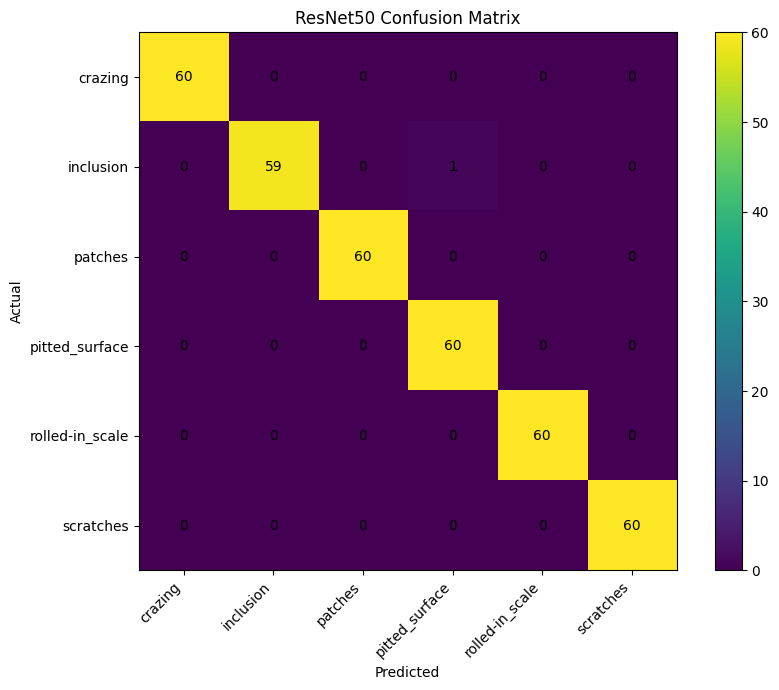

In [ ]:
# COnfusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
#Check prediction accuracy
from collections import Counter

print(
    Counter(y_pred)
)

Counter({np.int64(3): 61, np.int64(0): 60, np.int64(2): 60, np.int64(4): 60, np.int64(5): 60, np.int64(1): 59})


Save the resnet model

In [ ]:
model_path = (
    "/content/drive/MyDrive/"
    "ML_Projects/AI_industrial_defect_detection/"
    "resnet50.keras"
)

resnet_model.save(model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/resnet50.keras


Save the class mapping

In [ ]:
import json

class_mapping = {
    "0": "crazing",
    "1": "inclusion",
    "2": "patches",
    "3": "pitted_surface",
    "4": "rolled-in_scale",
    "5": "scratches"
}

mapping_path = (
    "/content/drive/MyDrive/"
    "ML_Projects/AI_industrial_defect_detection/"
    "class_mapping.json"
)

with open(mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Class mapping saved.")

Save the class names

In [ ]:
import json

class_names_path = (
    "/content/drive/MyDrive/"
    "ML_Projects/AI_industrial_defect_detection/"
    "class_names.json"
)

with open(class_names_path, "w") as f:
    json.dump(class_names, f)

print("Class names saved.")

Class names saved.


In [ ]:
print("Train samples:", resnet_train_generator.samples)
print("Validation samples:", resnet_val_generator.samples)

Train samples: 1440
Validation samples: 360


# **EfficientNet**

EfficientNet generators

In [10]:
efficient_train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

efficient_val_datagen = ImageDataGenerator()

In [11]:
efficient_train_generator = efficient_train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

efficient_val_generator = efficient_val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


Load EfficientNetB0

In [12]:
from tensorflow.keras.applications import EfficientNetB0

base_efficient = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze the backbone

In [13]:
base_efficient.trainable = False

Build the classifier

In [14]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_efficient(
    inputs,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    6,
    activation="softmax"
)(x)

efficientnet_model = Model(
    inputs,
    outputs
)

Compile

In [15]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6
)

Train

In [17]:
history_efficient = efficientnet_model.fit(
    efficient_train_generator,
    validation_data=efficient_val_generator,
    epochs=5,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 592s 13s/step - accuracy: 0.8069 - loss: 0.5937 - val_accuracy: 0.9750 - val_loss: 0.2131 - learning_rate: 0.0010
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9639 - loss: 0.1287 - val_accuracy: 0.9833 - val_loss: 0.1167 - learning_rate: 0.0010
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9833 - loss: 0.0685 - val_accuracy: 0.9778 - val_loss: 0.0841 - learning_rate: 0.0010
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9826 - loss: 0.0531 - val_accuracy: 0.9833 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9833 - loss: 0.0511 - val_accuracy: 0.9778 - val_loss: 0.0716 - learning_rate: 0.0010


Prediction

In [18]:
efficient_val_generator.reset()

efficient_predictions = efficientnet_model.predict(
    efficient_val_generator,
    verbose=1
)

efficient_y_pred = np.argmax(
    efficient_predictions,
    axis=1
)

efficient_y_true = efficient_val_generator.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


Metrics

In [19]:
efficient_accuracy = accuracy_score(
    efficient_y_true,
    efficient_y_pred
)

efficient_precision = precision_score(
    efficient_y_true,
    efficient_y_pred,
    average="weighted"
)

efficient_recall = recall_score(
    efficient_y_true,
    efficient_y_pred,
    average="weighted"
)

efficient_f1 = f1_score(
    efficient_y_true,
    efficient_y_pred,
    average="weighted"
)

print(f"Accuracy : {efficient_accuracy:.4f}")
print(f"Precision: {efficient_precision:.4f}")
print(f"Recall   : {efficient_recall:.4f}")
print(f"F1 Score : {efficient_f1:.4f}")

Accuracy : 0.9778
Precision: 0.9790
Recall   : 0.9778
F1 Score : 0.9775


Classification Report

In [20]:
print(
    classification_report(
        efficient_y_true,
        efficient_y_pred,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

        crazing       0.98      1.00      0.99        60
      inclusion       1.00      0.88      0.94        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.97      0.98      0.98        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.92      1.00      0.96        60

       accuracy                           0.98       360
      macro avg       0.98      0.98      0.98       360
   weighted avg       0.98      0.98      0.98       360



Confusion Matrix

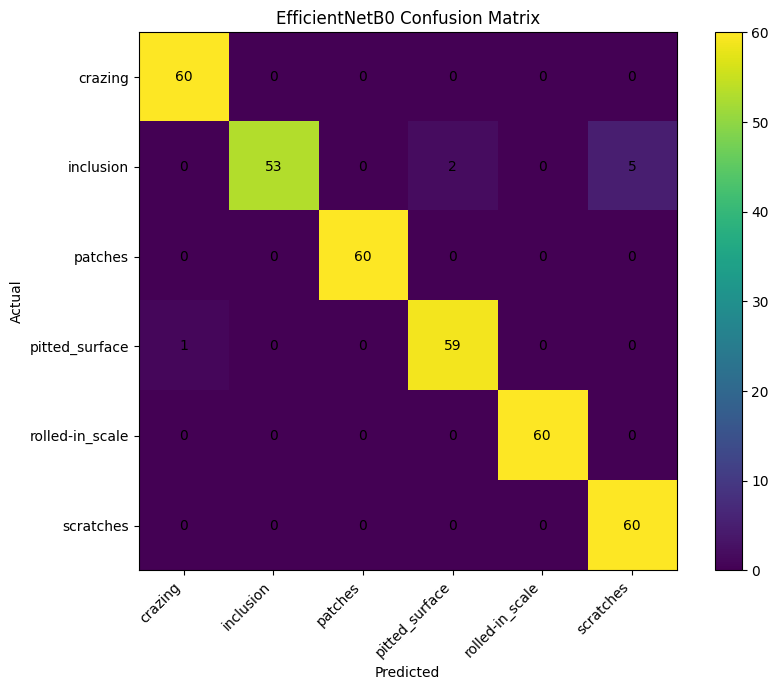

In [21]:
efficient_cm = confusion_matrix(
    efficient_y_true,
    efficient_y_pred
)

plt.figure(figsize=(9, 7))

plt.imshow(efficient_cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            efficient_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

final comparison cell

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50",
        "EfficientNetB0"
    ],
    "Accuracy": [
        0.1667,
        0.9972,
        0.9778
    ],
    "Precision": [
        0.03,
        0.9973,
        0.9790
    ],
    "Recall": [
        0.1667,
        0.9972,
        0.9778
    ],
    "F1 Score": [
        0.05,
        0.9972,
        0.9775
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.1667,0.0300,0.1667,0.0500
1,ResNet50,0.9972,0.9973,0.9972,0.9972
2,EfficientNetB0,0.9778,0.9790,0.9778,0.9775


plot accuracy:

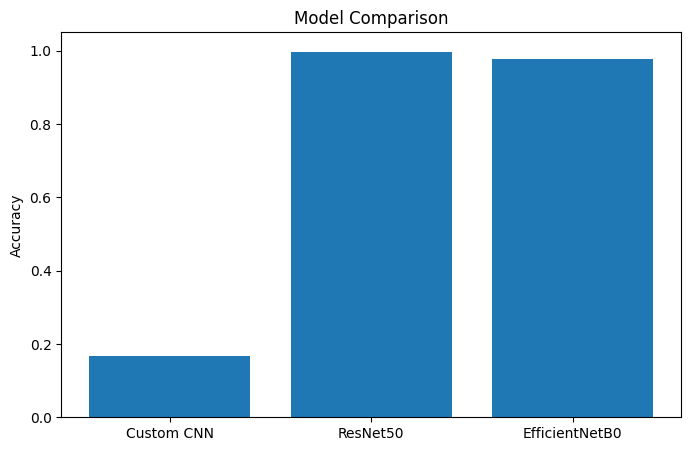

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1.05)

plt.show()

save EfficientNet

In [24]:
efficientnet_model.save(
    "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/efficientnetb0.keras"
)